# 04 - Large Scale Transformer Training

First serious large-scale behavioral cloning training
for Riichi Mahjong transformer policy learning.

Configuration:
- 100k training samples
- 10k validation samples
- transformer baseline
- top-k validation metrics

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from src.data.dataset import MahjongDataset
from src.data.collator import MahjongCollator

from src.models.transformer_model import (
    MahjongTransformer
)

from src.training.train_loop import (
    train_model
)

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [4]:
train_dataset = MahjongDataset(
    db_path="../data/raw/datasets_positive.db",

    table_name="Discard",

    limit=100000,

    offset=0,
)

val_dataset = MahjongDataset(
    db_path="../data/raw/datasets_positive.db",

    table_name="Discard",

    limit=10000,

    offset=100000,
)

In [5]:
collator = MahjongCollator()

In [8]:
train_loader = DataLoader(
    train_dataset,

    batch_size=64,

    shuffle=True,

    collate_fn=collator.collate,
)

val_loader = DataLoader(
    val_dataset,

    batch_size=64,

    shuffle=False,

    collate_fn=collator.collate,
)

In [9]:
model = MahjongTransformer(
    embedding_dim=128,

    num_heads=8,

    num_layers=4,

    ff_dim=512,
).to(device)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
)

In [11]:
checkpoint_dir = (
    "../checkpoints/baseline_transformer"
)

In [12]:
metrics = train_model(
    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    optimizer=optimizer,

    criterion=criterion,

    device=device,

    epochs=15,

    checkpoint_dir=checkpoint_dir,
)

/home/julia/miniforge3/envs/riichi-ai/lib/python3.11/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1739474893324/work/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(



Epoch 1
Train Loss: 1.9960
Train Accuracy: 0.3462
Val Loss: 1.9091
Val Accuracy: 0.3858
Val Top-3: 0.6188
Val Top-5: 0.7539
Checkpoint saved to ../checkpoints/baseline_transformer/epoch_1.pt

Epoch 2
Train Loss: 1.7929
Train Accuracy: 0.4224
Val Loss: 1.6528
Val Accuracy: 0.4615
Val Top-3: 0.7152
Val Top-5: 0.8202
Checkpoint saved to ../checkpoints/baseline_transformer/epoch_2.pt

Epoch 3
Train Loss: 1.5953
Train Accuracy: 0.4868
Val Loss: 1.5234
Val Accuracy: 0.5060
Val Top-3: 0.7605
Val Top-5: 0.8494
Checkpoint saved to ../checkpoints/baseline_transformer/epoch_3.pt

Epoch 4
Train Loss: 1.4474
Train Accuracy: 0.5346
Val Loss: 1.3927
Val Accuracy: 0.5474
Val Top-3: 0.7951
Val Top-5: 0.8753
Checkpoint saved to ../checkpoints/baseline_transformer/epoch_4.pt

Epoch 5
Train Loss: 1.3510
Train Accuracy: 0.5652
Val Loss: 1.3617
Val Accuracy: 0.5596
Val Top-3: 0.8078
Val Top-5: 0.8875
Checkpoint saved to ../checkpoints/baseline_transformer/epoch_5.pt

Epoch 6
Train Loss: 1.2936
Train Accura

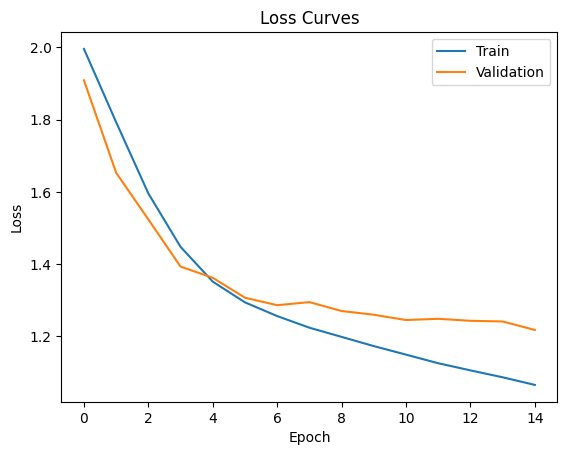

In [13]:
import matplotlib.pyplot as plt

plt.plot(
    metrics["train_losses"],
    label="Train"
)

plt.plot(
    metrics["val_losses"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curves")

plt.legend()

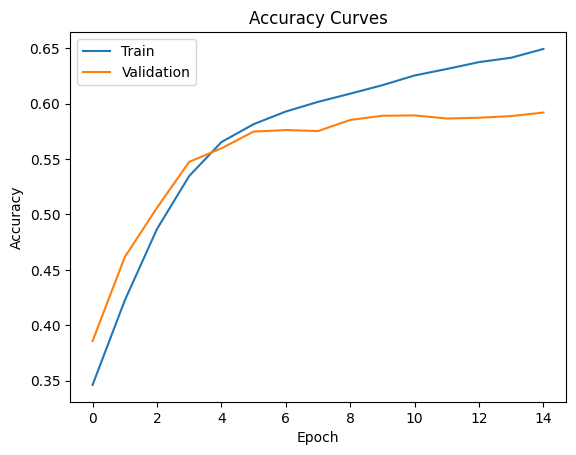

In [14]:
plt.plot(
    metrics["train_accuracies"],
    label="Train"
)

plt.plot(
    metrics["val_accuracies"],
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Accuracy Curves")

plt.legend()

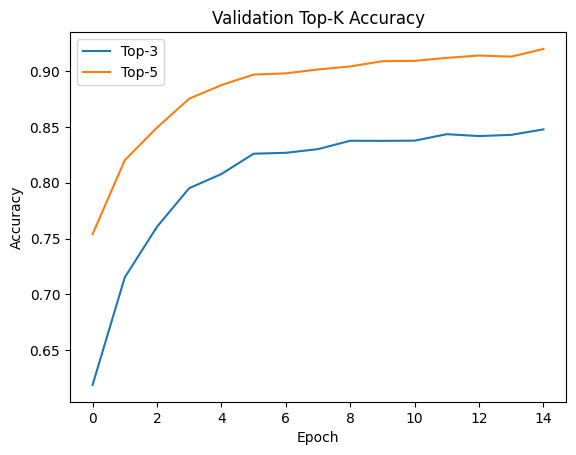

In [15]:
plt.plot(
    metrics["val_top3s"],
    label="Top-3"
)

plt.plot(
    metrics["val_top5s"],
    label="Top-5"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Validation Top-K Accuracy")

plt.legend()